In [1]:
!copy %cd%\..\Ebay\Server\Controllers\Contracts\Ebay.yaml %cd%
!rmdir %cd%\openapi_client\ /s /q
!docker run --rm -v %cd%:/local openapitools/openapi-generator-cli:v7.3.0 generate -i /local/Ebay.yaml -g python-pydantic-v1 -o /local/client --additional-properties=generateSourceCodeOnly=true
!move %cd%/client/openapi_client %cd%/openapi_client
!rmdir %cd%\client\ /s /q

        1 file(s) copied.
[main] INFO  o.o.codegen.DefaultGenerator - Generating with dryRun=false
[main] INFO  o.o.c.ignore.CodegenIgnoreProcessor - Output directory (/local/client) does not exist, or is inaccessible. No file (.openapi-generator-ignore) will be evaluated.
[main] INFO  o.o.codegen.DefaultGenerator - OpenAPI Generator: python-pydantic-v1 (client)
[main] INFO  o.o.codegen.DefaultGenerator - Generator 'python-pydantic-v1' is considered stable.
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - Environment variable PYTHON_POST_PROCESS_FILE not defined so the Python code may not be properly formatted. To define it, try 'export PYTHON_POST_PROCESS_FILE="/usr/local/bin/yapf -i"' (Linux/Mac)
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - NOTE: To enable file post-processing, 'enablePostProcessFile' must be set to `true` (--enable-post-process-file for CLI).
[main] INFO  o.o.c.l.PythonPydanticV1ClientCodegen - Environment variable PYTHON_POST_PROCESS_FILE not define

In [1]:
from openapi_client import LotInfoShort, ProductWithId
from openapi_client import ApiClient, Configuration
from openapi_client.api import DefaultApi
import requests
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from datetime import datetime

In [2]:
server = "naks42.ru"
port = 17443
clientId = "Ebay.Python"
secret = "ac4ab670-ae20-451a-ab4a-3a20275e807d"

In [3]:
unknown_price_discount = 0.8

In [4]:
def get_access_token(url, client_id, client_secret):
    response = requests.post(
        url,
        data={"grant_type": "client_credentials"},
        auth=(client_id, client_secret),
    )
    return response.json()["access_token"]

token = get_access_token(f"https://{server}:{port}/connect/token", clientId, secret)

client = ApiClient(
    configuration=Configuration(host=f'https://{server}:{port}/api/ebay/v1'), header_name='Authorization',
    header_value='Bearer ' + token)

api = DefaultApi(client)

currencies = api.get_currencies()
currency_rates = {}
for currency in currencies:
    if (datetime.now() - datetime.strptime(currencies[0].last_update, '%Y-%m-%dT%H:%M:%S.%fZ')).days > 1:
        raise Exception("exchange rate isn't accurate " + currency.ebay_name)
    currency_rates[currency.ebay_name] = currency.rate

productRowsExcluded = {'search_queries'}
lotRowsExcluded = {'seller', 'located_in', 'purchase_history'}
purchaseExcluded = {}

products: List[ProductWithId] = api.get_all_products()
df = pd.DataFrame()

for product in products:
    print(f'Processing {product.name}')
    lots: List[LotInfoShort] = api.get_lots(product_id=product.id)

    productRow = {}
    for key, value in product.__dict__.items():
        if key not in productRowsExcluded:
            productRow[f'product_{key}'] = value

    dataFrameArray = []
    for lot in lots:
        lotRow = productRow.copy()
        for key, value in lot.__dict__.items():
            if key not in lotRowsExcluded:
                lotRow[f'lot_{key}'] = value

        for purchase in lot.purchase_history:
            purchaseRow = lotRow.copy()
            for key, value in purchase.__dict__.items():
                if key not in purchaseExcluded:
                    purchaseRow[f'purchase_{key}'] = value
            dataFrameArray.append(purchaseRow)

    df = pd.concat([df, pd.DataFrame(dataFrameArray)], ignore_index=True)

df.lot_title_change_date = pd.to_datetime(df.lot_title_change_date)
df.purchase_var_date = pd.to_datetime(df.purchase_var_date)
df = df[df.purchase_var_date > df.lot_title_change_date]
df['purchase_price_filled_nulls'] = df.purchase_price.fillna(df.lot_price * unknown_price_discount)
df['exchange_rate'] = df.lot_currency.map(currency_rates)

df['purchase_total_price'] = df.purchase_price_filled_nulls * df.purchase_quantity #+ df.lot_shipping + (df.lot_shipping_additional * (df.purchase_quantity - 1))
df['purchase_total_price_usd'] = df.purchase_total_price / df.exchange_rate
df['total_price_per_pcs_usd'] = df.purchase_total_price_usd / (df.lot_pcs * df.purchase_quantity)

Processing 12Z1L POLAM
Processing 12Ж1Л
Processing 12П17Л
Processing 1Б10-17
Processing 2Ж27Л
Processing 6CC31 TESLA
Processing 6Е1П
Processing 6Е3П
Processing 6И1П
Processing 6И1П-ЕВ
Processing 6Н15П
Processing 6Н16Б-В
Processing 6Н18Б-В
Processing 6Н1П
Processing 6Н1П-В
Processing 6Н1П-ВИ
Processing 6Н1П-Е
Processing 6Н1П-ЕВ
Processing 6Н1П-ЕВ СОВТЕК
Processing 6Н1П Совтек
Processing 6Н2П
Processing 6Н2П-В
Processing 6Н2П-Е
Processing 6Н2П-ЕВ
Processing 6Н2П-ЕР
Processing 6Н2П КИТАЙ
Processing 6Н3П
Processing 6Н3П-ДР
Processing 6Н3П-Е
Processing 6Н3П-ЕВ
Processing 6Н3П-И
Processing 6Н5П
Processing 6Н7С
Processing 6Н9С
Processing 6П13С
Processing 6П14П
Processing 6П14П-В
Processing 6П14П-ЕВ
Processing 6П14П-ЕР
Processing 6П14П-К
Processing 6П15П
Processing 6П15П-ЕВ
Processing 6П15П-ЕР
Processing 6П1П
Processing 6П1П-В
Processing 6П1П-Е
Processing 6П1П-ЕВ
Processing 6П21С
Processing 6П7С
Processing 6С19П
Processing 6С19П-В
Processing 6С19П-ВР
Processing 6С1П
Processing 6С2П
Processing 

In [5]:
df = df[(df.product_name == '6П14П')]

In [6]:
df['lot_manual_condition_id'].value_counts()

lot_manual_condition_id
usedAndMatched      285
usedAndNotTested     50
usedAndTested        50
newAndMatched        37
newAndTested         11
newNotTested          9
Name: count, dtype: int64

In [ ]:
%%sql


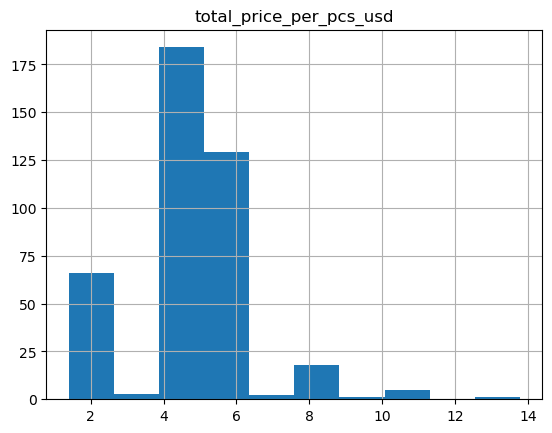

In [18]:
df_hist = df[(df.lot_manual_condition_id == 'usedAndMatched')   ]
df_hist.hist('total_price_per_pcs_usd', weights=df_hist.purchase_quantity);

In [131]:
df_hist.sort_values('total_price_per_pcs_usd')

,product_id,product_name,product_last_check_time,lot_lot_id,lot_name,lot_pcs,lot_shipping_country,lot_currency,lot_price,lot_shipping,...,lot_manual_condition_id,lot_title_change_date,purchase_price,purchase_quantity,purchase_var_date,purchase_price_filled_nulls,exchange_rate,purchase_total_price,purchase_total_price_usd,total_price_per_pcs_usd
1558,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,364535388124,4pcs 6P14P ( EL84 6BQ5 ) SOVIET VACUUM PENTODE...,4,Germany,US $,22.00,8.50,...,newAndMatched,1970-01-01 00:00:00+00:00,NaN,1,2023-11-20 10:13:00+00:00,17.60,1.0,17.60,17.60,4.400
1559,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,364535388124,4pcs 6P14P ( EL84 6BQ5 ) SOVIET VACUUM PENTODE...,4,Germany,US $,22.00,8.50,...,newAndMatched,1970-01-01 00:00:00+00:00,22.0,1,2023-11-18 18:41:25+00:00,22.00,1.0,22.00,22.00,5.500
1423,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,1,2023-11-08 22:34:39+00:00,27.00,1.0,27.00,27.00,6.750
1422,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,2,2023-11-16 02:02:47+00:00,27.00,1.0,54.00,54.00,6.750
1421,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,1,2023-11-16 13:27:22+00:00,27.00,1.0,27.00,27.00,6.750
1419,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,1,2023-12-02 19:29:13+00:00,27.00,1.0,27.00,27.00,6.750
1418,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,1,2023-12-03 15:08:09+00:00,27.00,1.0,27.00,27.00,6.750
1417,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,1,2023-12-04 00:59:44+00:00,27.00,1.0,27.00,27.00,6.750
1416,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,1,2023-12-04 18:28:09+00:00,27.00,1.0,27.00,27.00,6.750
1415,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,145191346462,4pcs New 6P14P Matched Quad Gold Grid tube EL8...,4,Germany,US $,34.00,12.00,...,newAndMatched,2023-09-30 06:37:57+00:00,27.0,3,2023-12-12 07:48:41+00:00,27.00,1.0,81.00,81.00,6.750


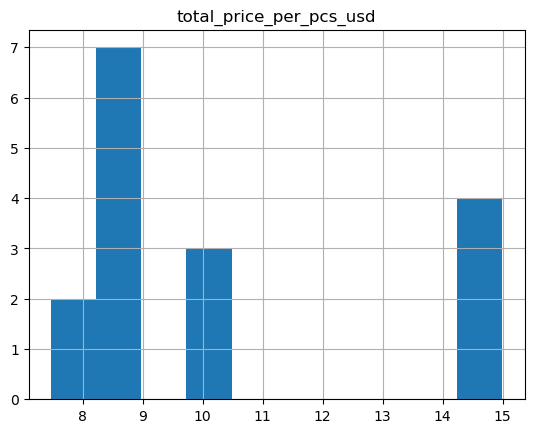

In [132]:
df_hist = df[df.lot_manual_condition_id == 'newNotTested']
df_hist.hist('total_price_per_pcs_usd', weights=df_hist.purchase_quantity);

In [133]:
df_hist.sort_values('total_price_per_pcs_usd')

,product_id,product_name,product_last_check_time,lot_lot_id,lot_name,lot_pcs,lot_shipping_country,lot_currency,lot_price,lot_shipping,...,lot_manual_condition_id,lot_title_change_date,purchase_price,purchase_quantity,purchase_var_date,purchase_price_filled_nulls,exchange_rate,purchase_total_price,purchase_total_price_usd,total_price_per_pcs_usd
1493,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,196049322146,2x 6P14P EL84 6BQ5 Same Date Code 03-1979 Refl...,2,Germany,US $,14.95,9.0,...,newNotTested,2023-11-07 11:53:30+00:00,14.95,1,2023-11-23 12:12:01+00:00,14.95,1.0,14.95,14.95,7.475
1494,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,196049322146,2x 6P14P EL84 6BQ5 Same Date Code 03-1979 Refl...,2,Germany,US $,14.95,9.0,...,newNotTested,2023-11-07 11:53:30+00:00,14.95,1,2023-11-10 16:58:39+00:00,14.95,1.0,14.95,14.95,7.475
1483,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,186202873731,"6P14P ( EL84, 6BQ5 ) NOS Soviet Military tubes",1,Lithuania,US $,9.95,9.0,...,newNotTested,1970-01-01 00:00:00+00:00,8.95,4,2023-12-27 11:01:39+00:00,8.95,1.0,35.80,35.80,8.950
1484,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,186202873731,"6P14P ( EL84, 6BQ5 ) NOS Soviet Military tubes",1,Lithuania,US $,9.95,9.0,...,newNotTested,1970-01-01 00:00:00+00:00,8.95,1,2023-12-15 08:24:00+00:00,8.95,1.0,8.95,8.95,8.950
1485,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,186202873731,"6P14P ( EL84, 6BQ5 ) NOS Soviet Military tubes",1,Lithuania,US $,9.95,9.0,...,newNotTested,1970-01-01 00:00:00+00:00,8.95,2,2023-12-14 15:09:40+00:00,8.95,1.0,17.90,17.90,8.950
1481,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,186202873731,"6P14P ( EL84, 6BQ5 ) NOS Soviet Military tubes",1,Lithuania,US $,9.95,9.0,...,newNotTested,1970-01-01 00:00:00+00:00,9.95,1,2024-02-09 04:32:19+00:00,9.95,1.0,9.95,9.95,9.950
1482,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,186202873731,"6P14P ( EL84, 6BQ5 ) NOS Soviet Military tubes",1,Lithuania,US $,9.95,9.0,...,newNotTested,1970-01-01 00:00:00+00:00,9.95,1,2024-01-07 17:20:46+00:00,9.95,1.0,9.95,9.95,9.950
1529,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,266615307578,4 x REFLECTOR 6P14P EL84 6BQ5 Tubes,4,Germany,US $,40.00,14.0,...,newNotTested,1970-01-01 00:00:00+00:00,40.0,1,2024-01-27 06:45:34+00:00,40.00,1.0,40.00,40.00,10.000
1522,a42a07b8-b1a1-465f-b625-edac46d65337,6П14П,2024-02-02T11:33:47.160Z,266459682012,1x 6P14P 6BQ5 EL84M Russian tubes Soviet USSR ...,1,Bulgaria,US $,14.99,8.2,...,newNotTested,1970-01-01 00:00:00+00:00,14.99,4,2024-01-21 21:00:27+00:00,14.99,1.0,59.96,59.96,14.990


In [110]:
df[["lot_lot_id","total_price_per_pcs_usd", "purchase_total_price_usd", "lot_pcs", "purchase_quantity", "lot_shipping", "lot_shipping_additional", "purchase_price_filled_nulls"]]

,lot_lot_id,total_price_per_pcs_usd,purchase_total_price_usd,lot_pcs,purchase_quantity,lot_shipping,lot_shipping_additional,purchase_price_filled_nulls
1133,115043977132,2.795,27.95,10,1,8.95,8.95,19.0
1134,115043977132,2.795,27.95,10,1,8.95,8.95,19.0
1135,115043977132,2.795,27.95,10,1,8.95,8.95,19.0
1136,115043977132,2.415,48.30,10,2,8.95,8.95,15.2
1137,115043977132,2.415,72.45,10,3,8.95,8.95,15.2
...,...,...,...,...,...,...,...,...
1564,394134039609,4.250,17.00,4,1,9.50,3.50,7.5
1565,394134039609,2.750,44.00,4,4,9.50,3.50,6.0
1566,394134039609,3.875,15.50,4,1,9.50,3.50,6.0
1567,394134039609,2.750,44.00,4,4,9.50,3.50,6.0
